In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
import pandas as pd

# 读取数据
df = pd.read_csv(r'C:\Users\sbjalz\OneDrive - SAS\Desktop\开发代码\太阳谷\chickenfarming\Alex\winter0515_clean.csv',encoding='utf-8')

In [6]:
# 定义温度列名范围（从 -2 到 36 天，共 39 个字段）
temp_cols = [f'Temp_MEAN_{i}' for i in range(-2, 37)]

# 检查列是否存在
missing_cols = [col for col in temp_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"列名缺失: {missing_cols}")

In [8]:
# 计算每条记录的温度缺失数量
missing_counts = df[temp_cols].isnull().sum(axis=1)

In [10]:
# 删除缺失超过6天的记录
df_cleaned = df[missing_counts <= 6].copy()

In [12]:
# 计算每列的均值（忽略缺失值）
column_means = df_cleaned[temp_cols].mean()

# 使用列均值填充缺失值
df_cleaned[temp_cols] = df_cleaned[temp_cols].fillna(column_means)

In [216]:
# 6. 提取特征和目标变量
X = df_cleaned[temp_cols].values  # (N, 39)
y = df_cleaned[['MORTALITY_RATE']].values  # (N, 1)

In [218]:
from sklearn.preprocessing import StandardScaler

# 标准化温度序列
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [220]:
# 标准化输出
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)  # (N, 1)

In [222]:
# 8. 转换为 PyTorch 张量
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(-1)  # (N, 39, 1)
y_tensor = torch.tensor(y, dtype=torch.float32)

In [224]:
# 9. 划分训练集和验证集
train_X, val_X, train_y, val_y = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

In [226]:
# 10. 构建 Dataset 和 DataLoader
class ChickenDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [228]:
train_dataset = ChickenDataset(train_X, train_y)
val_dataset = ChickenDataset(val_X, val_y)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [230]:
# ================== 固定位置编码 ==================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# ================== Transformer 模型定义 ==================
class TransformerModel(nn.Module):
    def __init__(self, input_dim=1, d_model=128, nhead=8, num_layers=6, output_dim=1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len=39)
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            norm_first=True,  # 显式启用残差连接和层归一化
            dropout=0.1       # 添加 Dropout 防止过拟合
        )
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.LayerNorm(d_model),  # 全连接层前加 LayerNorm
            nn.Linear(d_model, output_dim)
        )

    def forward(self, src):
        src = self.embedding(src)  # (batch_size, seq_len, d_model)
        src = self.positional_encoding(src)  # 添加固定位置编码
        src = self.transformer_encoder(src)  # (batch_size, seq_len, d_model)
        src = src.mean(dim=1)  # 全局平均池化
        output = self.fc(src)  # (batch_size, output_dim)
        return output

In [232]:
# ================== 初始化模型、损失函数和优化器 ==================
model = TransformerModel()
criterion = nn.HuberLoss(delta=1.0)  # 使用 Huber Loss 替代 MSE
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, verbose=True)

# ================== 早停机制 ==================
patience = 5
best_val_loss = float('inf')
counter = 0

C:\Users\sbjalz\AppData\Local\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\sbjalz\AppData\Local\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [234]:
# ================== 训练循环 ==================
def train(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for X, y in loader:
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X, y in loader:
            output = model(X)
            loss = criterion(output, y)
            total_loss += loss.item()
    return total_loss / len(loader)

In [236]:
# 主训练循环
epochs = 200
for epoch in range(epochs):
    train_loss = train(model, train_loader, criterion, optimizer)
    val_loss = validate(model, val_loader, criterion)
    
    # 更新学习率调度器
    scheduler.step(val_loss)
    
    # 早停机制
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_transformer.pth")  # 保存最佳模型
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}.")
            break

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

Epoch 1: Train Loss=1.0287, Val Loss=0.0692
Epoch 2: Train Loss=0.0659, Val Loss=0.0046
Epoch 3: Train Loss=0.0202, Val Loss=0.0066
Epoch 4: Train Loss=0.0076, Val Loss=0.0068
Epoch 5: Train Loss=0.0039, Val Loss=0.0035
Epoch 6: Train Loss=0.0022, Val Loss=0.0020
Epoch 7: Train Loss=0.0015, Val Loss=0.0010
Epoch 8: Train Loss=0.0012, Val Loss=0.0009
Epoch 9: Train Loss=0.0012, Val Loss=0.0006
Epoch 10: Train Loss=0.0010, Val Loss=0.0006
Epoch 11: Train Loss=0.0010, Val Loss=0.0006
Epoch 12: Train Loss=0.0010, Val Loss=0.0006
Epoch 13: Train Loss=0.0011, Val Loss=0.0006
Epoch 14: Train Loss=0.0010, Val Loss=0.0006
Epoch 15: Train Loss=0.0010, Val Loss=0.0006
Epoch 16: Train Loss=0.0010, Val Loss=0.0006
Epoch 17: Train Loss=0.0010, Val Loss=0.0005
Epoch 18: Train Loss=0.0010, Val Loss=0.0005
Epoch 19: Train Loss=0.0010, Val Loss=0.0006
Epoch 20: Train Loss=0.0010, Val Loss=0.0005
Epoch 21: Train Loss=0.0010, Val Loss=0.0006
Epoch 22: Train Loss=0.0010, Val Loss=0.0006
Epoch 23: Train Los

In [237]:
# 保存模型
torch.save(model.state_dict(), "transformer_model.pth")

In [284]:
# ================== 5. 模型评估 ==================
model.load_state_dict(torch.load("transformer_model.pth"))
model.eval()

with torch.no_grad():
    scaler = StandardScaler()
    y_pred_scaled = model(val_X).numpy()  # 预测输出 (N, 2)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)  # 反标准化
    y_true = scaler_y.inverse_transform(val_y.numpy()) # 真实值

    # 计算评估指标
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== 模型评估结果 ===")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

C:\Users\sbjalz\AppData\Local\Temp\ipykernel_12100\2723865766.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("transformer_model.pth"))



=== 模型评估结果 ===
MAE: 0.0013
MSE: 0.0000
RMSE: 0.0016
R² Score: 0.2676


In [310]:
def optimize_temperature_sequence():
    # 直接创建目标形状的叶张量 (1, 39, 1)
    temperature_seq = torch.tensor([[[20.0] * 39]], dtype=torch.float32, requires_grad=True)
    
    # 定义优化器
    optimizer = torch.optim.Adam([temperature_seq], lr=0.1)
    
    # 定义训练轮数
    epochs = 500
    mortality_history = []

    # 先拟合 StandardScaler（可选：在训练前使用训练数据拟合）
    scaler = StandardScaler()

    for epoch in range(epochs):
        # 将温度序列转换为模型输入格式 (1, 39, 1)
        input_array = temperature_seq.detach().numpy()  # (1, 39, 1)
        
        # 展平为二维数组 (39, 1) 以进行标准化
        input_array = input_array.reshape(-1, input_array.shape[-1])  # (39, 1)
        input_array = scaler.fit_transform(input_array)  # 标准化
        input_array = input_array.reshape(1, 39, 1)  # 恢复为 (1, 39, 1)
        
        input_tensor = torch.tensor(input_array, dtype=torch.float32)  # 转换回 Tensor

        # 模型预测输出（假设输出为死亡率）
        with torch.enable_grad():  # 允许梯度计算
            outputs = model(input_tensor)  # 输入形状 (1, 39, 1)
            mortality = outputs.squeeze()  # 直接提取死亡率
        
        # 反向传播：最小化死亡率
        optimizer.zero_grad()
        mortality.backward()
        optimizer.step()
        
        # 限制温度范围 [0, 40]
        with torch.no_grad():
            temperature_seq.data = torch.clamp(temperature_seq, min=0.0, max=40.0)
        
        # 记录结果
        mortality_history.append(mortality.item())
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Mortality: {mortality.item():.4f}")

    # 反标准化温度序列
    optimal_temperature_seq = input_array  # 当前已经是标准化后的数据
    optimal_temperature_seq = optimal_temperature_seq.reshape(-1, input_array.shape[-1])  # (39, 1)
    optimal_temperature_seq = scaler.inverse_transform(optimal_temperature_seq)  # 反标准化
    optimal_temperature_seq = optimal_temperature_seq.reshape(1, 39, 1)  # 恢复为 (1, 39, 1)
    
    min_mortality = min(mortality_history)
    return optimal_temperature_seq, min_mortality, mortality_history

In [312]:
# ================== 3. 运行优化 ==================
optimal_seq, min_mortality, history = optimize_temperature_sequence()

Epoch 50/500, Mortality: 0.0996
Epoch 100/500, Mortality: 0.0996
Epoch 150/500, Mortality: 0.0996
Epoch 200/500, Mortality: 0.0996
Epoch 250/500, Mortality: 0.0996
Epoch 300/500, Mortality: 0.0996
Epoch 350/500, Mortality: 0.0996
Epoch 400/500, Mortality: 0.0996
Epoch 450/500, Mortality: 0.0996
Epoch 500/500, Mortality: 0.0996


ValueError: non-broadcastable output operand with shape (39,1) doesn't match the broadcast shape (39,39)

C:\Users\sbjalz\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sbjalz\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20129 (\N{CJK UNIFIED IDEOGRAPH-4EA1}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sbjalz\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sbjalz\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sbjalz\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED I

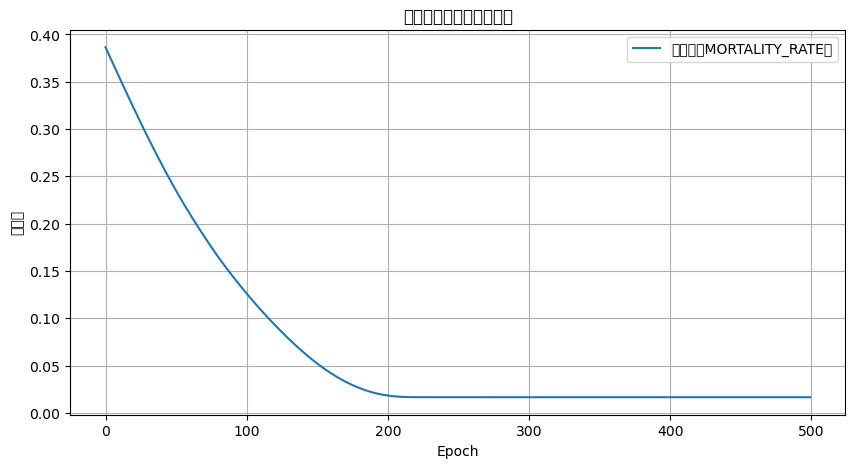

In [266]:
# ================== 4. 可视化结果 ==================
plt.figure(figsize=(10, 5))
plt.plot(history, label="死亡率（MORTALITY_RATE）")
plt.title("优化过程：最小化死亡率")
plt.xlabel("Epoch")
plt.ylabel("死亡率")
plt.legend()
plt.grid(True)
plt.show()

In [280]:
from sklearn.preprocessing import StandardScaler

# 标准化温度序列
scaler = StandardScaler()
optimal_seq_inv = scaler.inverse_transform(optimal_seq)

NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [272]:

# ================== 5. 输出最优温度序列 ==================
print("\n=== 最优温度序列 ===")
print("温度序列（39 天）:", [f"{temp:.2f}°C" for temp in optimal_seq])
print(f"最小化死亡率: {min_mortality:.4f}")


=== 最优温度序列 ===
温度序列（39 天）: ['3.58°C', '3.57°C', '3.59°C', '3.65°C', '3.67°C', '3.65°C', '3.61°C', '3.63°C', '3.65°C', '3.64°C', '3.64°C', '3.61°C', '3.50°C', '3.39°C', '3.38°C', '3.39°C', '3.44°C', '3.48°C', '3.52°C', '3.54°C', '3.49°C', '3.41°C', '3.33°C', '3.29°C', '3.34°C', '3.44°C', '3.57°C', '3.64°C', '3.65°C', '3.59°C', '3.52°C', '3.50°C', '3.49°C', '3.57°C', '3.59°C', '3.58°C', '3.51°C', '3.45°C', '3.45°C']
最小化死亡率: 0.0166
